**1. Importação das bibliotecas**

In [ ]:
#Instalando Dependências
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
##############################################################################
                 # Importação de bibliotecas e frameworks #

# Pandas e Numpy
import pandas as pd                                       # pandas e numpy
import numpy as np                                        # pandas e numpy
import matplotlib.pyplot as plt                           # Visualização (plotly e matplotlib)
import folium
from folium.plugins import HeatMap
import textwrap
import json
import requests
import warnings
from kmodes.kmodes import KModes
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import DBSCAN

**2. Lendo o CSV**

In [38]:
file_path = 'datatran2024.csv'
df = pd.read_csv(file_path, sep=";")
df

C:\Users\eduka\AppData\Local\Temp\ipykernel_7012\3011053825.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=";")


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,571789,01/01/2024,segunda-feira,03:56:00,ES,101,38,CONCEICAO DA BARRA,Ultrapassagem Indevida,Colisão lateral sentido oposto,...,1,1,1,1,3,-1.848.261,-3.992.379,SPRF-ES,DEL04-ES,UOP02-DEL04-ES
1,571804,01/01/2024,segunda-feira,04:50:00,PI,343,185,PIRIPIRI,Manobra de mudança de faixa,Colisão frontal,...,0,1,0,0,2,-429.603.281,-4.176.732.659,SPRF-PI,DEL02-PI,UOP01-DEL02-PI
2,571806,01/01/2024,segunda-feira,04:30:00,BA,116,578,BREJOES,Ingestão de álcool pelo condutor,Colisão frontal,...,0,1,2,0,4,-1.307.158.302,-399.611.107,SPRF-BA,DEL03-BA,UOP02-DEL03-BA
3,571818,01/01/2024,segunda-feira,06:30:00,SE,101,18,MALHADA DOS BOIS,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,...,1,0,2,1,3,-1.035.601.949,-3.690.552.235,SPRF-SE,DEL02-SE,UOP02-DEL02-SE
4,571838,01/01/2024,segunda-feira,05:00:00,MT,364,240,RONDONOPOLIS,Condutor deixou de manter distância do veículo...,Colisão traseira,...,0,2,1,0,3,-1.617.914.141,-5.478.905.337,SPRF-MT,DEL02-MT,UOP01-DEL02-MT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73151,661295,21/12/2024,sábado,07:00:00,PB,230,"135,2",CAMPINA GRANDE,Ausência de reação do condutor,Saída de leito carroçável,...,0,0,0,1,1,-728.210.346,-3.576.839.447,SPRF-PB,DEL02-PB,UOP01-DEL02-PB
73152,661307,01/12/2024,domingo,06:30:00,RJ,393,298,VOLTA REDONDA,Ausência de reação do condutor,Colisão frontal,...,0,0,0,2,2,-2.254.313.289,-4.411.298.586,SPRF-RJ,DEL07-RJ,UOP02-DEL07-RJ
73153,661377,09/07/2024,terça-feira,16:20:00,ES,101,"101,5",SOORETAMA,Desrespeitar a preferência no cruzamento,Colisão transversal,...,0,0,0,3,2,-1.898.833.904,-3.999.933.491,SPRF-ES,DEL04-ES,UOP02-DEL04-ES
73154,661576,17/12/2024,terça-feira,21:35:00,RJ,101,391,RIO DE JANEIRO,Frear bruscamente,Colisão traseira,...,0,1,0,1,2,-22.894.827,-4.368.492,SPRF-RJ,DEL03-RJ,UOP01-DEL03-RJ


**3. Exploração das colunas**

In [39]:
df.info()
df_describe = df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73156 entries, 0 to 73155
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      73156 non-null  object
 1   data_inversa            73156 non-null  object
 2   dia_semana              73156 non-null  object
 3   horario                 73156 non-null  object
 4   uf                      73156 non-null  object
 5   br                      73156 non-null  int64 
 6   km                      73156 non-null  object
 7   municipio               73156 non-null  object
 8   causa_acidente          73156 non-null  object
 9   tipo_acidente           73156 non-null  object
 10  classificacao_acidente  73155 non-null  object
 11  fase_dia                73156 non-null  object
 12  sentido_via             73156 non-null  object
 13  condicao_metereologica  73156 non-null  object
 14  tipo_pista              73156 non-null  object
 15  tr

**4. Perguntas de negócio**

- **Acidentes por estado**

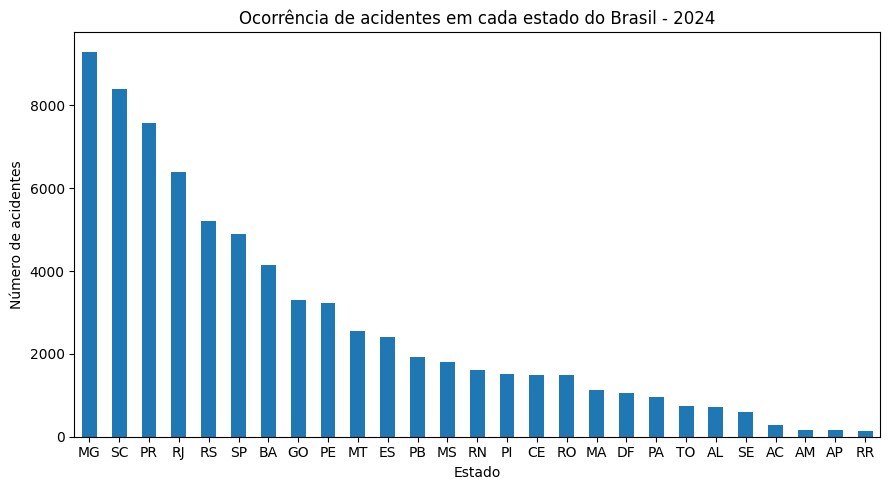

In [56]:
# Observando a contagem de acidentes por estado em 2024
df['uf'].value_counts().head()
top_estados = df['uf'].value_counts()
plt.figure(figsize=(9, 5))
top_estados.plot(kind='bar')
plt.title('Ocorrência de acidentes em cada estado do Brasil - 2024')
plt.xlabel('Estado')
plt.ylabel('Número de acidentes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- **Horário e dia da semana que mais ocorrem acidentes**

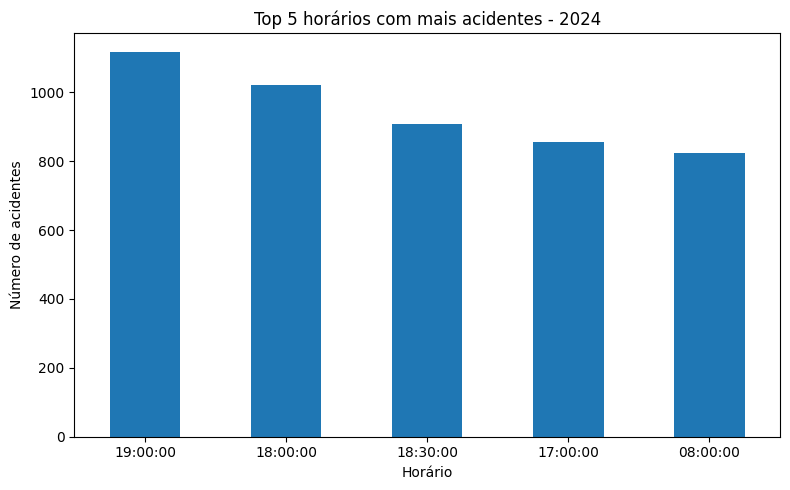

Faixa de horário com mais acidentes: das 17h às 19h


In [69]:
# Observando em qual dia e horário mais ocorrem
df['horario'].value_counts().head()
top_horarios = df['horario'].value_counts().head(5)
plt.figure(figsize=(8, 5))
top_horarios.plot(kind='bar')
plt.title('Top 5 horários com mais acidentes - 2024')
plt.xlabel('Horário')
plt.ylabel('Número de acidentes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
## Adicionar gráfico e horário médio de acidentes (em média, em qual horário ocorrem mais acidentes)
df['hora'] = pd.to_datetime(df['horario'], format='%H:%M:%S').dt.hour
faixa = df['hora'].value_counts().head(3).index.sort_values()
print(f'Faixa de horário com mais acidentes: das {faixa[0]:02d}h às {faixa[-1]:02d}h')

dia_semana
domingo          11741
sábado           11641
sexta-feira      11300
segunda-feira    10208
quinta-feira      9570
quarta-feira      9384
terça-feira       9312
Name: count, dtype: int64


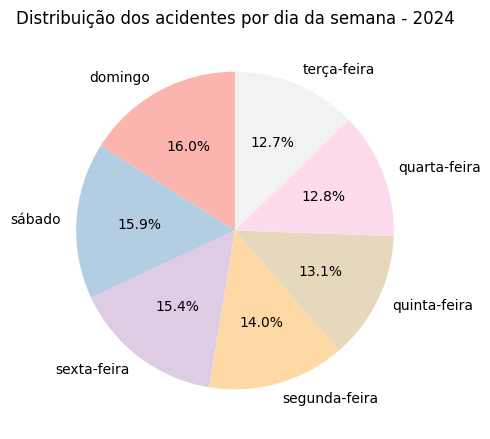

In [70]:
df['dia_semana'].value_counts()
dias = df['dia_semana'].value_counts()
print(dias)
plt.figure(figsize=(5, 5))
plt.pie(dias.values, labels=dias.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1(np.linspace(0, 1, len(dias))))
plt.title('Distribuição dos acidentes por dia da semana - 2024')
plt.tight_layout()
plt.show()

- **Brs com maior ocorrecias de acidentes dentro do estado de Minas Gerais**


BR com mais acidentes em MG: BR-381 (2793 ocorrências).


br
381    2793
40     1791
116    1383
262    1058
365     634
50      599
251     276
153     263
267     156
459     101
Name: count, dtype: int64

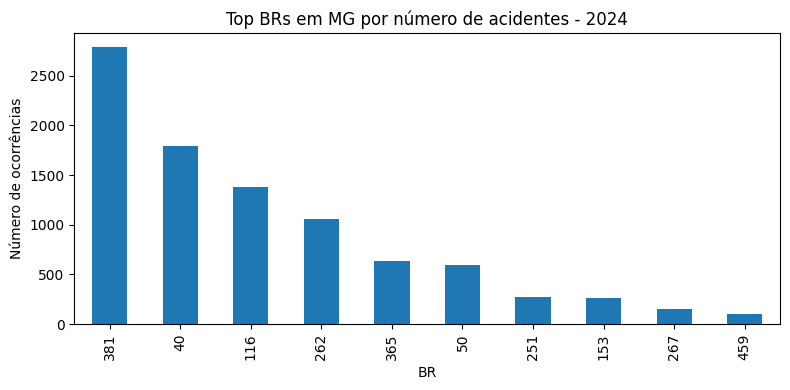

In [71]:
# BRs mais críticas dentro do estado com mais acidentes
acidentes_por_uf = df["uf"].value_counts()
estado_top = acidentes_por_uf.idxmax()
br_no_estado_top = df.loc[df["uf"] == estado_top, "br"].value_counts()

print(f"\nBR com mais acidentes em {estado_top}: BR-{br_no_estado_top.idxmax()} ({br_no_estado_top.max()} ocorrências).")
display(br_no_estado_top.head(10))

br_no_estado_top.head(10).plot(kind="bar", figsize=(8, 4))
plt.title(f"Top BRs em {estado_top} por número de acidentes - 2024")
plt.xlabel("BR")
plt.ylabel("Número de ocorrências")
plt.tight_layout()
plt.show()

- **Maior causa de acidentes**

Top 10 causas de acidentes:

A principal causa dos acidentes é: Reação tardia ou ineficiente do condutor (10920 ocorrências).


causa_acidente
Reação tardia ou ineficiente do condutor                     10920
Ausência de reação do condutor                               10664
Acessar a via sem observar a presença dos outros veículos     6958
Condutor deixou de manter distância do veículo da frente      4460
Velocidade Incompatível                                       4347
Manobra de mudança de faixa                                   4213
Ingestão de álcool pelo condutor                              3854
Demais falhas mecânicas ou elétricas                          3390
Transitar na contramão                                        2461
Condutor Dormindo                                             2136
Name: count, dtype: int64

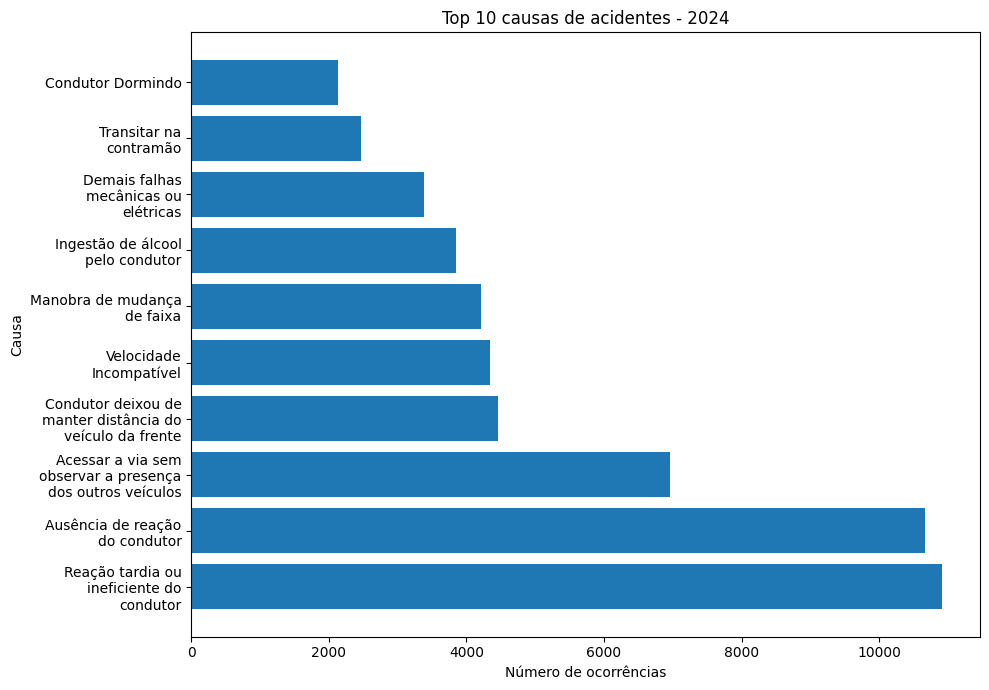

In [52]:
# Qual é a maior causa dos acidentes?
causas = df["causa_acidente"].value_counts()

print("Top 10 causas de acidentes:")
print(f"\nA principal causa dos acidentes é: {causas.idxmax()} ({causas.max()} ocorrências).")
display(causas.head(10))

labels = [textwrap.fill(label, width=20) for label in causas.head(10).index]

plt.figure(figsize=(10, 7))
plt.barh(labels, causas.head(10).values)
plt.title("Top 10 causas de acidentes - 2024")
plt.xlabel("Número de ocorrências")
plt.ylabel("Causa")
plt.tight_layout()
plt.show()

- **Acidentes por condição meteorológica**

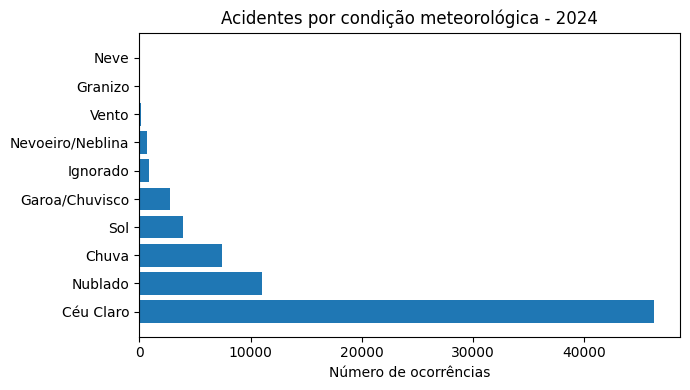

In [81]:
# O clima influencia nos acidentes?
clima = df['condicao_metereologica'].value_counts()
plt.figure(figsize=(7, 4))
plt.barh(clima.index, clima.values)
plt.title("Acidentes por condição meteorológica - 2024")
plt.xlabel("Número de ocorrências")
plt.tight_layout()
plt.show()

- **Acidentes por hora x condição meteorológica**

Tabela de acidentes por hora x condição meteorológica:


condicao_metereologica,Chuva,Céu Claro,Garoa/Chuvisco,Granizo,Ignorado,Neve,Nevoeiro/Neblina,Nublado,Sol,Vento
hora,,,,,,,,,,
0,145,878,108,0,35,0,26,264,1,1
1,154,816,69,0,37,0,31,261,0,5
2,100,748,75,0,39,0,30,211,0,8
3,114,800,72,0,48,0,48,249,0,7
4,128,953,84,0,59,0,47,259,4,2
5,197,1427,100,0,57,0,93,336,26,4
6,305,2028,123,0,36,0,88,470,148,3
7,354,2960,152,0,23,0,57,653,395,2
8,309,2381,142,0,11,0,28,510,345,1


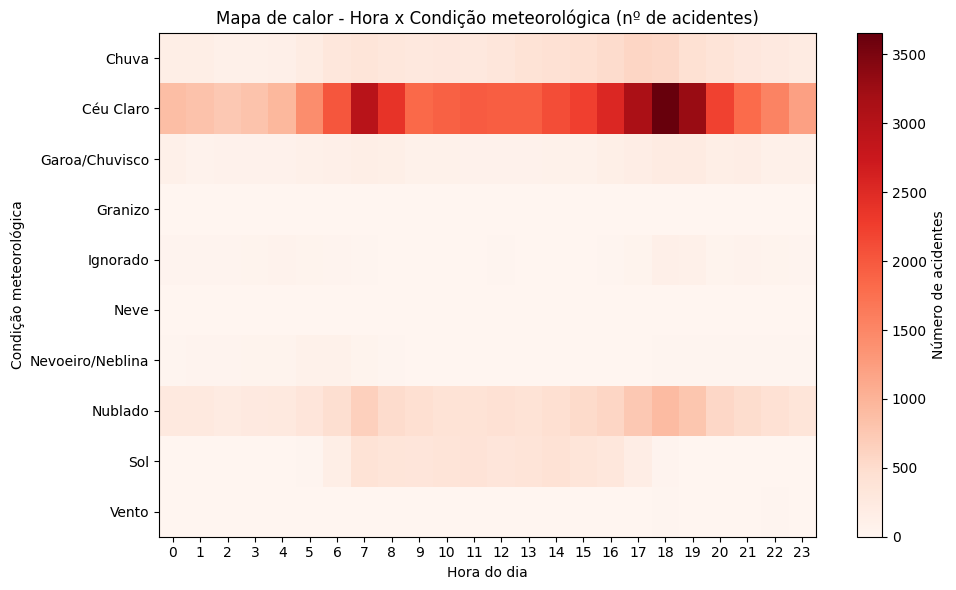


Tabela de acidentes por hora x principais causas:


causa_acidente,Acessar a via sem observar a presença dos outros veículos,Ausência de reação do condutor,Condutor deixou de manter distância do veículo da frente,Reação tardia ou ineficiente do condutor,Velocidade Incompatível
hora,,,,,
0,44,255,39,241,103
1,32,278,25,222,103
2,31,228,20,177,96
3,30,250,19,205,94
4,65,289,38,199,95
5,99,401,70,321,140
6,244,521,193,517,228
7,499,653,447,654,259
8,379,535,307,604,243


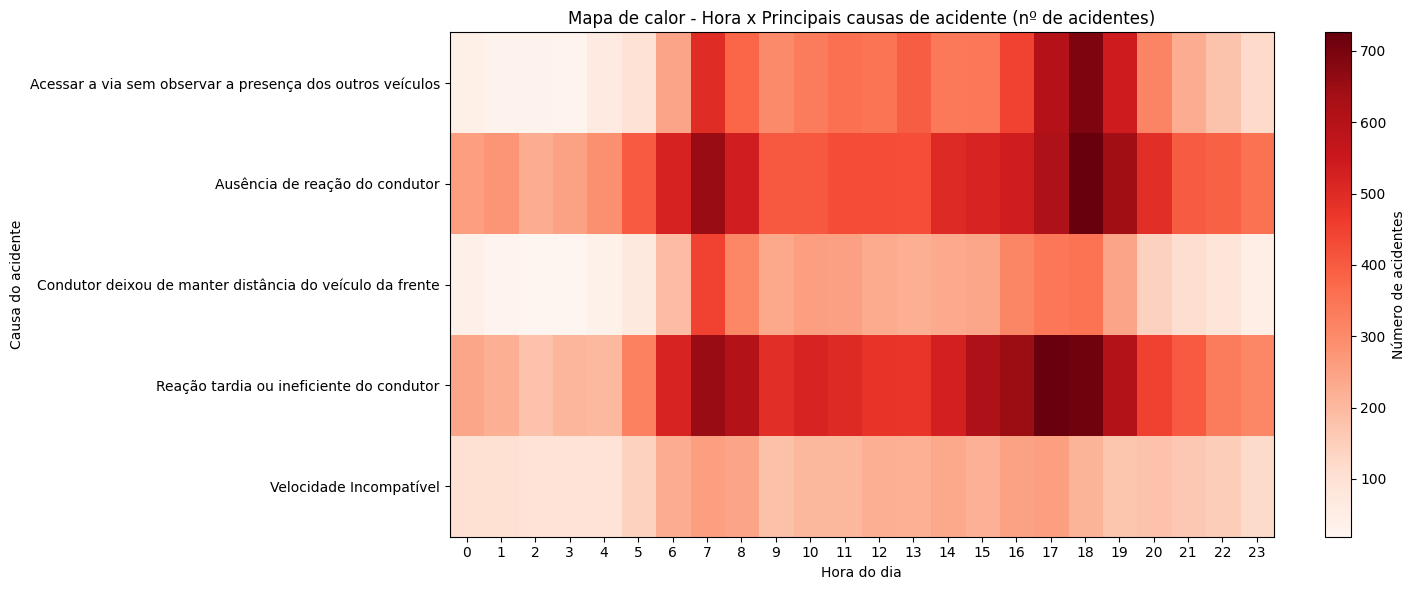

In [47]:
# Existe relação entre horário e clima com as causas de acidentes?

# Garante que a coluna "hora" existe
if "hora" not in df.columns:
    df["hora"] = pd.to_datetime(df["horario"], format="%H:%M:%S").dt.hour

# Tabela hora x condição climática
tabela_hora_clima = pd.pivot_table(
    df,
    index="hora",
    columns="condicao_metereologica",
    values="id",
    aggfunc="count"
).fillna(0).astype(int)

print("Tabela de acidentes por hora x condição meteorológica:")
display(tabela_hora_clima)

plt.figure(figsize=(10, 6))
plt.imshow(tabela_hora_clima.T, aspect="auto", cmap="Reds")
plt.colorbar(label="Número de acidentes")
plt.yticks(range(len(tabela_hora_clima.columns)), tabela_hora_clima.columns)
plt.xticks(range(0, 24), range(0, 24))
plt.xlabel("Hora do dia")
plt.ylabel("Condição meteorológica")
plt.title("Mapa de calor - Hora x Condição meteorológica (nº de acidentes)")
plt.tight_layout()
plt.show()

# Relação horário x principais causas de acidente
principais_causas = df["causa_acidente"].value_counts().head(5).index
df_causas_top = df[df["causa_acidente"].isin(principais_causas)]

tabela_hora_causa = pd.pivot_table(
    df_causas_top,
    index="hora",
    columns="causa_acidente",
    values="id",
    aggfunc="count"
).fillna(0)

print("\nTabela de acidentes por hora x principais causas:")
display(tabela_hora_causa)

plt.figure(figsize=(15, 6))
plt.imshow(tabela_hora_causa.T, aspect="auto", cmap="Reds")
plt.colorbar(label="Número de acidentes")
plt.yticks(range(len(tabela_hora_causa.columns)), tabela_hora_causa.columns)
plt.xticks(range(0, 24), range(0, 24))
plt.xlabel("Hora do dia")
plt.ylabel("Causa do acidente")
plt.title("Mapa de calor - Hora x Principais causas de acidente (nº de acidentes)")
plt.tight_layout()
plt.show()

## Por que a maioria dos acidentes ocorrem domingo no período das 17h às 19h?
Essa questão está relacionada principalmente em relação aos fatores:
- Falta de fiscalização
- Visibilidade menor
- Falta de atenção.
- Fadiga
Analisando o conjunto de dados, vemos que a maioria ocorrem domingo e sábado, isto é, são finais de semana. Isto pode estar relacionado com o fato de que as pessoas se importam menos com a segurança no trânsito nesses dias (https://www.portaldotransito.com.br/noticias/fiscalizacao-e-legislacao/estatisticas/estudo-mostra-que-mortes-no-transito-acontecem-mais-aos-finais-de-semana/). Além disso, dias de finais de semana possuem menos fiscalização, e são dias que a fadiga dos condutores fica maior.

## Por que os acidentes ocorrem mais em Minas Gerais do que em outros estados? E por que a colisão traseira é a mais comum?
Em relação a ser em Minas Gerais, vários fatores podem contribuir. O estado possui uma das rodovias mais perigosas do país, a BR-381, e isso pode estar relacionado com trechos perigosos e falta de sinalização. Já em relação a colisão traseira, a causa mais provável é a falta de atenção em relação aos condutores. Por conta de muitas vezes termos fluxo intenso de veículos e trechos perigosos, é preciso frear para evitar esse tipo de acidente, além de manter distância do veículo que está na frente.

## Mapa de calor

In [88]:
# =========================================
# 1. CARREGAR DADOS
# =========================================
df = pd.read_csv("datatran2024.csv", sep=";", low_memory=False)

ranking = df["uf"].value_counts().reset_index()
ranking.columns = ["uf", "acidentes"]

total_acidentes = ranking["acidentes"].sum()
ranking["percentual"] = (ranking["acidentes"] / total_acidentes * 100).round(2)

print(ranking)

# =========================================
# 2. CARREGAR GEOJSON DOS ESTADOS
# =========================================
geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
geojson_data = requests.get(geojson_url).json()

# =========================================
# 3. CALCULAR CENTROS (CENTROIDES) DOS ESTADOS
# =========================================
def calcular_centroid(coordinates):
    """ Calcula centroide médio da geometria do estado """
    longs = []
    lats = []

    def extract(coords):
        for c in coords:
            if isinstance(c[0], list):
                extract(c)
            else:
                longs.append(c[0])
                lats.append(c[1])

    extract(coordinates)
    return (sum(lats) / len(lats), sum(longs) / len(longs))

centroids = {}
for feature in geojson_data["features"]:
    uf = feature["properties"]["sigla"]
    coords = feature["geometry"]["coordinates"]
    centroids[uf] = calcular_centroid(coords)

# =========================================
# 4. MAPA BASE
# =========================================
mapa = folium.Map(
    location=[-14.235, -51.925],
    zoom_start=4,
    tiles="cartodbpositron"
)

# =========================================
# 5. CHOROPLETH (HEATMAP POR ESTADO)
# =========================================
folium.Choropleth(
    geo_data=geojson_data,
    name="choropleth",
    data=ranking,
    columns=["uf", "acidentes"],
    key_on="feature.properties.sigla",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.4,
    nan_fill_color="white",
    legend_name="Total de Acidentes por Estado (PRF 2024)"
).add_to(mapa)

# =========================================
# 6. ADICIONAR LABELS (UF + %)
# =========================================
for _, row in ranking.iterrows():
    uf = row["uf"]
    acidentes = row["acidentes"]
    pct = row["percentual"]
    lat, lon = centroids[uf]

    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            html=f"""
            <div style="font-size:12px; font-weight:bold; color:#000; text-align:center;">
                {uf}<br>{pct}% 
            </div>
            """
        )
    ).add_to(mapa)

# =========================================
# 7. SALVAR MAPA
# =========================================
mapa.save("heatmap_estados_brasil.html")
print("Mapa salvo como heatmap_estados_brasil.html")



    uf  acidentes  percentual
0   MG       9296       12.71
1   SC       8381       11.46
2   PR       7576       10.36
3   RJ       6389        8.73
4   RS       5206        7.12
5   SP       4883        6.67
6   BA       4151        5.67
7   GO       3305        4.52
8   PE       3230        4.42
9   MT       2554        3.49
10  ES       2395        3.27
11  PB       1920        2.62
12  MS       1803        2.46
13  RN       1606        2.20
14  PI       1520        2.08
15  CE       1500        2.05
16  RO       1483        2.03
17  MA       1138        1.56
18  DF       1056        1.44
19  PA        970        1.33
20  TO        735        1.00
21  AL        712        0.97
22  SE        597        0.82
23  AC        287        0.39
24  AM        169        0.23
25  AP        159        0.22
26  RR        135        0.18
Mapa salvo como heatmap_estados_brasil.html


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.2/102.4 MB 5.8 MB/s eta 0:00:18
    --------------------------------------- 1.3/102.4 MB 16.5 MB/s eta 0:00:07
   - -------------------------------------- 2.7/102.4 MB 21.5 MB/s eta 0:00:05
   - -------------------------------------- 3.1/102.4 MB 20.0 MB/s eta 0:00:05
   - -------------------------------------- 3.2/102.4 MB 14.6 MB/s eta 0:00:07
   - -------------------------------------- 4.6/102.4 MB 17.4 MB/s eta 0:00:06
   -- ------------------------------------- 6.1/102.4 MB 19.4 MB/s eta 0:00:05
   -- ------------------------------------- 6.3/102.4 MB 20.1 MB/s eta 0:00:05
   -- ------------------------------------- 7.1/102.4 MB 17.4 MB/s eta 0:00:06
   --- ------------------------------------ 8.4/102.4 MB 18.5 MB/s eta 0:00:06
   --- ------------------------------------ 9.8/102.4 MB 20.2 MB/s eta 0:00:05
   ---- ----------------------------------- 11.6/102.4 MB 21.

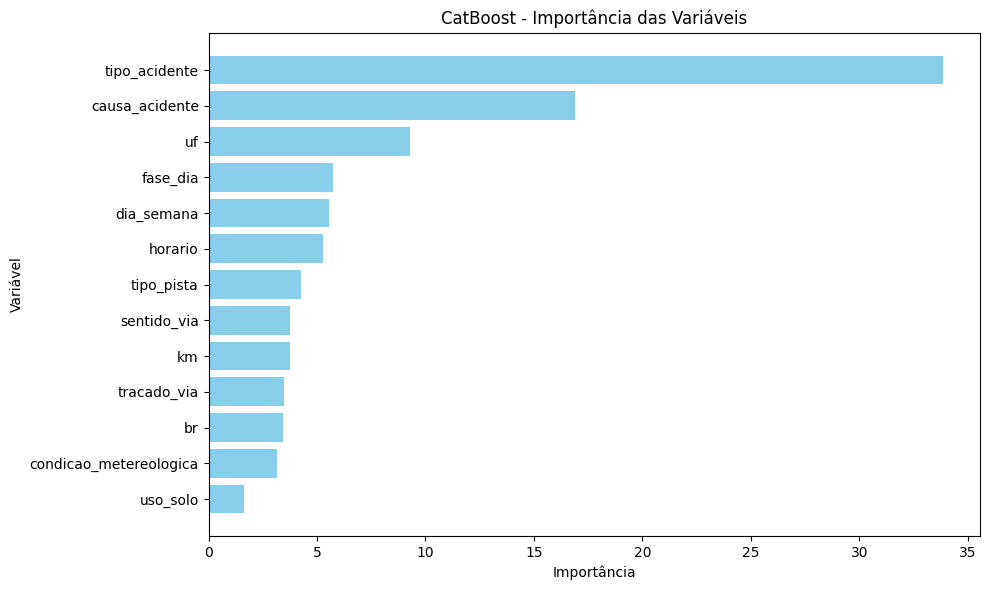

In [90]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
%pip install catboost
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# =========================================================
# 1. CARREGAR CSV
# =========================================================
df = pd.read_csv("datatran2024.csv", sep=";", low_memory=False)

# =========================================================
# 2. CRIAR VARIÁVEL ALVO (acidente grave)
# =========================================================
df["acidente_grave"] = (
    (df["classificacao_acidente"].isin(["Com Vítimas Fatais", "Com Vítimas Feridas"])) |
    (df["mortos"].astype(float) > 0) |
    (df["feridos_graves"].astype(float) > 0)
).astype(int)

# =========================================================
# 3. REMOVER COLUNAS QUE NÃO PODEM SER FEATURES
# =========================================================
drop_cols = [
    "id",
    "data_inversa",
    "municipio",
    "classificacao_acidente",
    "pessoas",
    "mortos",
    "feridos_leves",
    "feridos_graves",
    "feridos",
    "ilesos",
    "ignorados",
    "veiculos",
    "latitude",
    "longitude",
    "regional",
    "delegacia",
    "uop",
    "acidente_grave"
]

X = df.drop(columns=drop_cols)
y = df["acidente_grave"]

# =========================================================
# 4. TRATAR CATEGÓRICAS
# =========================================================
X_cat = X.copy()
categorical_cols = [col for col in X_cat.columns if X_cat[col].dtype == "object"]

for col in categorical_cols:
    X_cat[col] = X_cat[col].astype(str)

# =========================================================
# 5. TRAIN/TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_cat, y, test_size=0.25, random_state=42, stratify=y
)

# =========================================================
# 6. TREINAR CATBOOST
# =========================================================
cat = CatBoostClassifier(
    depth=6,
    iterations=400,
    learning_rate=0.05,
    verbose=False
)

cat.fit(X_train, y_train, cat_features=categorical_cols)

preds = cat.predict(X_test)

print("\n=== RESULTADOS - CatBoost ===")
print(classification_report(y_test, preds))

# =========================================================
# 7. IMPORTÂNCIA DAS FEATURES (CatBoost)
# =========================================================
df_imp = cat.get_feature_importance(prettified=True)
df_imp["Importances"] = df_imp["Importances"].astype(float)
df_imp = df_imp.sort_values("Importances", ascending=False)

print("\n=== Importância das Features - CatBoost ===")
print(df_imp)

# =========================================================
# 8. GRÁFICO SIMPLES DE IMPORTÂNCIA
# =========================================================
plt.figure(figsize=(10, 6))
plt.barh(df_imp["Feature Id"], df_imp["Importances"], color="skyblue")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.title("CatBoost - Importância das Variáveis")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 22985, cost: 557723.0
Run 1, iteration: 2/100, moves: 2501, cost: 557723.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 25705, cost: 562927.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 24162, cost: 554069.0
Run 3, iteration: 2/100, moves: 2, cost: 554069.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 22467, cost: 550299.0
Run 4, iteration: 2/100, moves: 4719, cost: 550299.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 20433, cost: 558163.0
Best run was number 4


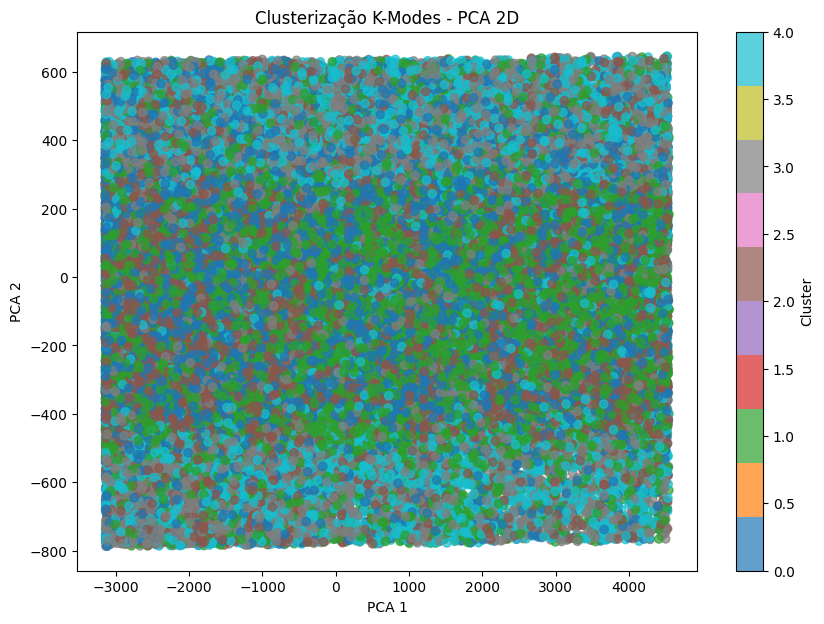


=== PERFIL DOS CLUSTERS (K-Modes) ===
                  dia_semana   horario  uf   br km  \
cluster_kmodes                                       
0               quarta-feira  15:00:00  SC  116  0   
1               quinta-feira  15:00:00  MG  116  0   
2               quinta-feira  10:00:00  SC  101  1   
3               quarta-feira  19:00:00  RJ  101  5   
4                     sábado  18:00:00  MG  116  1   

                                                   causa_acidente  \
cluster_kmodes                                                      
0               Acessar a via sem observar a presença dos outr...   
1                                  Ausência de reação do condutor   
2                        Reação tardia ou ineficiente do condutor   
3                                  Ausência de reação do condutor   
4                        Reação tardia ou ineficiente do condutor   

                            tipo_acidente     fase_dia  sentido_via  \
cluster_kmodes             

In [92]:
import pandas as pd
import numpy as np
from kmodes.kmodes import KModes
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import DBSCAN
import folium
from folium.plugins import MarkerCluster

df = pd.read_csv("datatran2024.csv", sep=";", low_memory=False)

cols = [
    "dia_semana",
    "horario",
    "uf",
    "br",
    "km",
    "causa_acidente",
    "tipo_acidente",
    "fase_dia",
    "sentido_via",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo"
]

data = df[cols].astype(str).fillna("NA")

km = KModes(n_clusters=5, init="Huang", n_init=5, verbose=1)
clusters = km.fit_predict(data)

df["cluster_kmodes"] = clusters

data_encoded = data.copy()
for col in data_encoded.columns:
    data_encoded[col] = LabelEncoder().fit_transform(data_encoded[col])

pca = PCA(n_components=2)
points_2d = pca.fit_transform(data_encoded)

df["pca1"] = points_2d[:, 0]
df["pca2"] = points_2d[:, 1]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df["pca1"], df["pca2"],
    c=df["cluster_kmodes"],
    cmap="tab10",
    alpha=0.7
)
plt.title("Clusterização K-Modes - PCA 2D")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

def fix_coord(x):
    x = str(x).replace(".", "").replace(",", ".")
    try:
        return float(x)
    except:
        return None

df["lat"] = df["latitude"].apply(fix_coord) / 1e7
df["lon"] = df["longitude"].apply(fix_coord) / 1e7

coords = df[["lat", "lon"]].dropna()

db = DBSCAN(eps=0.03, min_samples=25).fit(coords)
df.loc[coords.index, "geo_cluster"] = db.labels_

mapa = folium.Map(location=[-14.235, -51.925], zoom_start=4)
marker_cluster = MarkerCluster().add_to(mapa)

for _, row in df.dropna(subset=["lat", "lon"]).iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        color=f"#{int((row['geo_cluster']*9876543) if pd.notna(row['geo_cluster']) else 0) % 0xFFFFFF:06x}",
        fill=True,
        fill_opacity=0.7
    ).add_to(marker_cluster)

mapa

relatorio = df.groupby("cluster_kmodes")[cols].agg(lambda x: x.value_counts().index[0])

print("\n=== PERFIL DOS CLUSTERS (K-Modes) ===")
print(relatorio)

print("\n=== QUANTIDADE DE ACIDENTES POR CLUSTER ===")
print(df["cluster_kmodes"].value_counts())


## Conclusão 
Com base nos dados, os fatores que mais influenciam os acidentes nas rodovias brasileiras são, principalmente, relacionados ao comportamento dos condutores (desatenção, velocidade incompatível, falta de distância segura e manobras inadequadas), potencializados por horários críticos (fim de tarde/noite), finais de semana e, em menor grau, por condições climáticas adversas.